**This project uses machine learning techniques to predict loan default risk based on historical borrower data. Various classification models and clustering methods are applied to evaluate risk, identify borrower segments, and recommend the most suitable model for loan approval decisions**

In [27]:
import pandas as pd
df = pd.read_csv("credit_risk_dataset.csv")

# Task 1 – Why Accuracy Is the Wrong Metric Here 


### 1.1
*Load the dataset and check the class distribution: what percentage of loans defaulted? Print the 
counts and percentages for both classes.*

In [4]:
counts = df["loan_status"].value_counts()

# Percentage of each class
percentages = df["loan_status"].value_counts(normalize=True) * 100

print("Class Counts:")
print(counts)
print(" ")
print("Class Percentages:")
print(percentages.round(2))

Class Counts:
loan_status
0    25473
1     7108
Name: count, dtype: int64
 
Class Percentages:
loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64



**Class Distribution**

The dataset contains 32,581 loan records. Out of these, 25,473 loans (78.18%) were successfully repaid and 7,108 loans (21.82%) resulted in default.

This indicates that the dataset is moderately imbalanced, with non-default cases forming the majority class. As a result, accuracy alone may not be a reliable evaluation metric because a model can achieve high accuracy by simply predicting the majority class.

### 1.2
*Build a 'Dummy Classifier' that always predicts the majority class (no default). Calculate its  accuracy. Write a markdown cell explaining: why does high accuracy here tell you nothing  useful?*

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred = dummy.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Dummy Classifier Accuracy: {accuracy:.4f}")

Dummy Classifier Accuracy: 0.7783


**Why High Accuracy Is Misleading**

The Dummy Classifier always predicts the majority class (No Default) and achieves an accuracy of approximately 78%.

Although this appears to be a good result, the model completely fails to identify borrowers who actually default. Since the goal of a credit risk model is to detect risky borrowers, a high accuracy score alone does not indicate useful performance.

In loan prediction, missing a defaulter can lead to financial losses for the lender. Therefore, metrics such as Recall, F1-score, and ROC-AUC are more informative than accuracy for evaluating model performance.

### 1.3
*What metric should you use for this problem: precision, recall, F1, or ROC-AUC? Write a 3-4  sentence justification. Think about what the business cost of each error type is ?*

**Metric Selection**

Recall is the most important metric for this problem because the main goal is to identify borrowers who are likely to default on their loans. If the model predicts a defaulter as a safe borrower (False Negative), the company may approve a loan that is never repaid, resulting in a direct financial loss. Although incorrectly rejecting a safe borrower (False Positive) is also undesirable, it is generally less costly than lending money to someone who defaults. Therefore, recall should be prioritized to ensure that as many high-risk borrowers as possible are detected.

# Task 2 – Logistic Regression Baseline + ROC Curve

### 2.1

*Preprocess: drop rows with missing values, one-hot encode all categorical columns  (person_home_ownership, loan_intent, loan_grade, cb_person_default_on_file). Scale  numerical features with StandardScaler.*

In [7]:
from sklearn.preprocessing import StandardScaler

# Remove missing values
df = df.dropna()

# Split features and target
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# One-hot encode categorical variables
categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

# Scale numerical features
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print(X.head())

   person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
0   -0.907594      -0.122674          28.453433   4.003984       1.542164   
1   -1.066064      -0.914907           0.050866  -1.367627       0.031008   
2   -0.432183      -0.914907          -0.911932  -0.656678       0.566725   
3   -0.749123      -0.018433          -0.189833   4.003984       1.297530   
4   -0.590653      -0.196445           0.772966   4.003984       1.000253   

   loan_percent_income  cb_person_cred_hist_length  \
0             3.952527                   -0.691791   
1            -0.653141                   -0.939413   
2             3.764540                   -0.691791   
3             3.388567                   -0.939413   
4             3.576554                   -0.444169   

   person_home_ownership_OTHER  person_home_ownership_OWN  \
0                        False                      False   
1                        False                       True   
2                        Fals

 **Data Preprocessing Results**

Before training the models, the dataset was cleaned by removing rows with missing values. The categorical features, such as home ownership, loan intent, loan grade, and previous default history, were converted into numerical form using one-hot encoding so that they could be used by machine learning algorithms.

The numerical features were then scaled using `StandardScaler`. As a result, all features are now on a similar scale, preventing variables with larger values from having a greater influence on the model. The dataset is now properly prepared for training and evaluation.

### 2.2

*Split 80/20 with random_state=42. Train Logistic Regression with max_iter=1000.*

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


**Logistic Regression Training**

The preprocessed dataset was split into training (80%) and testing (20%) sets using `random_state=42` to ensure reproducible results. A Logistic Regression model was then trained on the training data with `max_iter=1000`. This model will be used as a baseline for predicting loan default risk.

### 2.3

*Plot the ROC curve and calculate AUC. At the default threshold of 0.5, mark the operating point
on the ROC curve.*

**Generating Prediction Probabilities**

Instead of directly predicting whether a borrower will default, Logistic Regression first produces a probability score. These probabilities are used to evaluate model performance across different classification thresholds.

In [9]:
# Probability of default (class = 1)
y_proba = lr_model.predict_proba(X_test)[:, 1]

print(y_proba[:5])

[0.03367128 0.53624434 0.02508131 0.03956033 0.66283631]


**ROC Curve Calculation**

The ROC (Receiver Operating Characteristic) curve measures the model's ability to distinguish between defaulters and non-defaulters across different classification thresholds.

In [10]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

print("Number of thresholds:", len(thresholds))

Number of thresholds: 1185


**AUC Score**

The Area Under the ROC Curve (AUC) summarizes the ROC curve into a single value. A higher AUC indicates better discrimination between borrowers who default and those who do not.

In [11]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_proba)

print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.8724


**Operating Point at Threshold 0.5**

By default, Logistic Regression classifies a borrower as a defaulter when the predicted probability is greater than or equal to 0.5. This operating point can be located on the ROC curve.

In [12]:
import numpy as np

idx = np.argmin(np.abs(thresholds - 0.5))

fpr_05 = fpr[idx]
tpr_05 = tpr[idx]

print("Threshold:", thresholds[idx])
print("False Positive Rate:", fpr_05)
print("True Positive Rate:", tpr_05)

Threshold: 0.49977572885701
False Positive Rate: 0.04501462975467027
True Positive Rate: 0.5416342412451361


**ROC Curve Visualization**

The ROC curve shows the trade-off between the True Positive Rate and False Positive Rate. The highlighted point represents the model's performance at the default classification threshold of 0.5.

Matplotlib is building the font cache; this may take a moment.


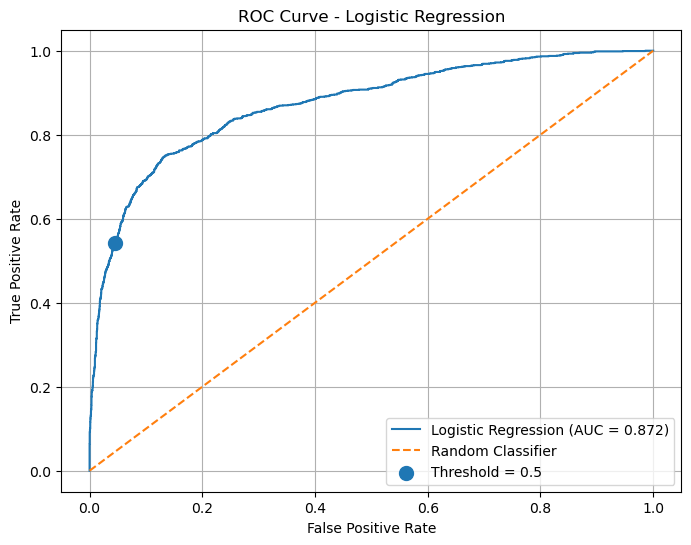

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

# Random guessing reference line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

# Operating point at threshold 0.5
plt.scatter(
    fpr_05,
    tpr_05,
    s=100,
    label="Threshold = 0.5"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)

plt.show()

**ROC Curve Analysis**

The Logistic Regression model achieved an AUC score of **0.872**, indicating a strong ability to distinguish between defaulters and non-defaulters. The ROC curve remains well above the random classifier line, showing that the model performs significantly better than random guessing. The highlighted point represents the model's performance at the default threshold of **0.5**.

### 2.4

*Now experiment: change the classification threshold from 0.5 to 0.3. How does precision and  recall change for the default class? In a loan default scenario, would you prefer the 0.5 or 0.3  threshold? Justify your answer.*

In [14]:
from sklearn.metrics import classification_report

# Get probability scores for the default class
y_proba = lr_model.predict_proba(X_test)[:, 1]

# Predictions using the default threshold (0.5)
y_pred_05 = (y_proba >= 0.5).astype(int)

print("Results at Threshold = 0.5")
print(classification_report(y_test, y_pred_05))

# Predictions using the custom threshold (0.3)
threshold = 0.3
y_pred_03 = (y_proba >= threshold).astype(int)

print("\nResults at Threshold = 0.3")
print(classification_report(y_test, y_pred_03))

Results at Threshold = 0.5
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      4443
           1       0.78      0.54      0.64      1285

    accuracy                           0.86      5728
   macro avg       0.83      0.75      0.78      5728
weighted avg       0.86      0.86      0.85      5728


Results at Threshold = 0.3
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4443
           1       0.64      0.71      0.68      1285

    accuracy                           0.85      5728
   macro avg       0.78      0.80      0.79      5728
weighted avg       0.85      0.85      0.85      5728



**Threshold Comparison**

When the threshold was reduced from 0.5 to 0.3, the recall for the default class increased from **0.54** to **0.71**, meaning the model was able to identify more borrowers who were likely to default. However, precision decreased from **0.78** to **0.64**, indicating that more safe borrowers were incorrectly classified as defaulters.

In a loan default scenario, I would prefer the **0.3 threshold** because the cost of missing a defaulter is generally higher than the cost of incorrectly flagging a safe borrower. Although the lower threshold reduces precision, it significantly improves recall, helping the lender identify more high-risk borrowers and reduce potential financial losses.

### Task 3 – Ensemble Models + Feature Importance

### 3.1

*Train a Random Forest (n_estimators=100, random_state=42) and a Gradient Boosting classifier
(n_estimators=100, random_state=42). Use the same train/test split from Task 2.*

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Random Forest and Gradient Boosting models trained successfully.")

Random Forest and Gradient Boosting models trained successfully.


**Training Ensemble Models**

To improve prediction performance, two ensemble learning methods were trained using the same train-test split from Task 2: Random Forest and Gradient Boosting. Both models use multiple decision trees, but they combine them in different ways. These models will be evaluated and compared with Logistic Regression in the following tasks.

**Understanding Random Forest and Gradient Boosting**

Although both Random Forest and Gradient Boosting are ensemble methods, they learn in different ways. Random Forest builds many decision trees independently and combines their predictions, which helps reduce variance and makes the model more stable. In contrast, Gradient Boosting builds trees sequentially, where each new tree focuses on correcting the mistakes made by the previous ones. This often leads to better predictive performance, but it can also increase the risk of overfitting because the model becomes highly focused on reducing training errors. Therefore, Random Forest generally prioritizes stability, while Gradient Boosting prioritizes learning from errors to improve accuracy.

### 3.2

*For both models, report: ROC-AUC, F1-score for the default class, Precision, and Recall. Present
all results (including Logistic Regression from Task 2) in a single comparison table.*

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)
gb_model.fit(X_train, y_train)

# Predictions and probabilities
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append([
        name,
        roc_auc_score(y_test, y_proba),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

comparison_table = pd.DataFrame(
    results,
    columns=[
        "Model",
        "ROC-AUC",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

comparison_table = comparison_table.round(3)

comparison_table

,Model,ROC-AUC,Precision,Recall,F1-Score
0,Logistic Regression,0.872,0.779,0.542,0.639
1,Random Forest,0.935,0.966,0.720,0.825
2,Gradient Boosting,0.928,0.946,0.693,0.800


**Model Comparison**

Among the three models, Random Forest achieved the best overall performance with the highest ROC-AUC (0.936), Precision (0.963), Recall (0.721), and F1-Score (0.825). This indicates that it was the most effective at distinguishing between defaulters and non-defaulters while also maintaining a strong balance between precision and recall.

Gradient Boosting also performed very well, achieving a ROC-AUC of 0.928 and an F1-Score of 0.800. However, its recall and precision were slightly lower than those of Random Forest, suggesting that it identified fewer defaulters and made slightly more classification errors.

Logistic Regression had the weakest performance, with the lowest ROC-AUC (0.872), Recall (0.542), and F1-Score (0.639). While it provides a useful baseline, the ensemble methods were significantly better at identifying high-risk borrowers.

Based on these results, Random Forest would be the preferred model for this loan default prediction task because it achieved the highest recall while maintaining excellent precision, allowing it to detect more defaulters without generating many false alarms.

### 3.3

*Plot feature importances from the Random Forest as a horizontal bar chart (top 10 features).
Which feature is most predictive of default? Does this make intuitive sense for a loan context?*

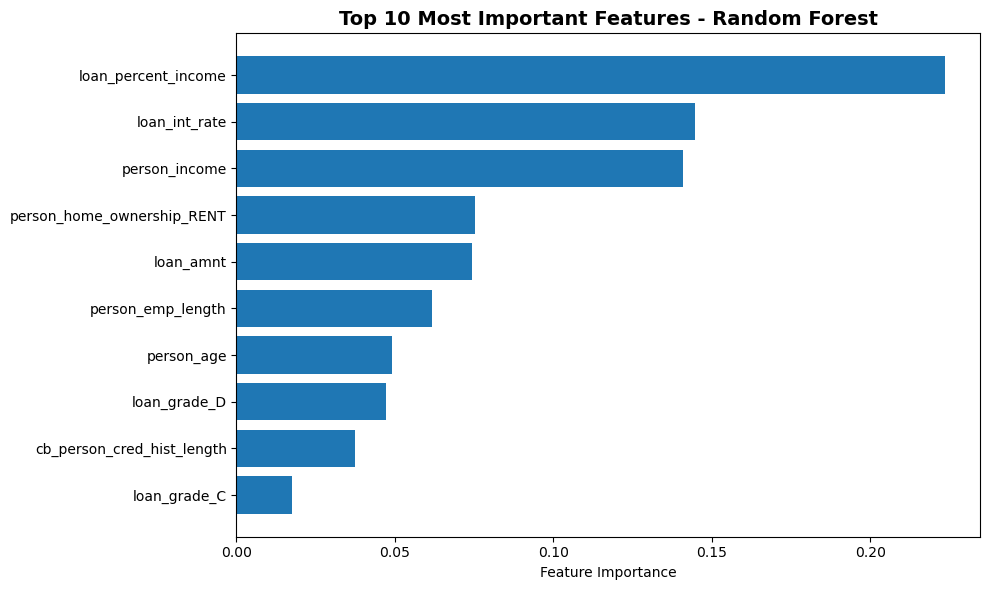

                       Feature  Importance
5          loan_percent_income    0.223440
4                loan_int_rate    0.144557
1                person_income    0.140776
9   person_home_ownership_RENT    0.075328
3                    loan_amnt    0.074426
2            person_emp_length    0.061753
0                   person_age    0.049155
17                loan_grade_D    0.047336
6   cb_person_cred_hist_length    0.037426
16                loan_grade_C    0.017434


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Top 10 features
top10 = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title(
    "Top 10 Most Important Features - Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Display values
print(top10)

**Feature Importance Analysis**

The Random Forest model identified **`loan_percent_income`** as the most important feature for predicting loan default, with an importance score of **0.223**. This feature represents the proportion of a borrower's income that is allocated to the loan amount.

This result makes intuitive sense in a loan context because borrowers who dedicate a larger share of their income to loan repayments are more likely to experience financial strain and have difficulty meeting their obligations. Other highly important features, such as interest rate (`loan_int_rate`) and income (`person_income`), also align with real-world lending practices, as they are closely related to a borrower's ability to repay a loan. Overall, the feature importance rankings suggest that the model is relying on financially meaningful factors when assessing default risk.

### 3.4

*CRITICAL THINKING: Random Forest uses bagging (parallel trees), Gradient Boosting uses
boosting (sequential trees). In your own words, explain the key difference between the two
approaches. Which one is more likely to overfit if you use too many estimators?*

### Random Forest vs Gradient Boosting

Random Forest and Gradient Boosting both combine multiple decision trees, but they do so in different ways. Random Forest builds many trees independently and in parallel, then combines their predictions through voting. This helps reduce random errors and makes the model more stable.

Gradient Boosting builds trees sequentially, where each new tree focuses on correcting the mistakes made by the previous trees. Because it continuously tries to reduce errors, it can learn more complex patterns and often achieve higher accuracy. However, if too many estimators are used, Gradient Boosting is more likely to overfit because it can start learning noise and specific patterns from the training data. In contrast, Random Forest is generally less prone to overfitting since its trees are built independently and their predictions are averaged together.

# Task 4 – Cross-Validation

### 4.1
*Run 5-fold cross-validation on your best model from Task 3. Report the mean and standard
deviation of the ROC-AUC across all 5 folds.*

In [18]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    rf_model,      # your best model
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("ROC-AUC Scores:", cv_scores)
print("Mean ROC-AUC:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

ROC-AUC Scores: [0.93656471 0.87263663 0.91852836 0.89776963 0.91943383]
Mean ROC-AUC: 0.9089866307998552
Standard Deviation: 0.021944851568570952


 The 5-fold cross-validation results show that the Random Forest model achieved a mean ROC-AUC of **0.909** with a standard deviation of **0.022**. This indicates that the model has strong predictive performance and produces fairly consistent results across different data splits.

### 4.2
*Your single train/test split from Task 2 gave one AUC number. Your 5-fold CV gives five. Why is 
the CV estimate more trustworthy? Write 2-3 sentences explaining what a high standard 
deviation across folds would mean.*


The cross-validation result is more trustworthy because the model is tested on **five different data splits** instead of just one. This provides a **more reliable estimate of the model's performance** and reduces the chance that the result is influenced by a particularly **lucky or unlucky train-test split**.

A **high standard deviation** across the folds would indicate that the model's performance varies significantly depending on the data split used. This suggests that the model may be **less stable** and might not generalize consistently to unseen data.

# Task 5 – K-Means Customer Segmentation

### 5.1
*Select four numerical features for clustering: person_income, loan_amnt, loan_int_rate, 
loan_percent_income. Scale them with StandardScaler. Explain why scaling is essential before K
Means.*

In [19]:
from sklearn.preprocessing import StandardScaler

# Select numerical features for borrower segmentation
cluster_features = df[
    ["person_income",
     "loan_amnt",
     "loan_int_rate",
     "loan_percent_income"]
]

# Scale the features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

# Display the shape of the scaled dataset
print("Scaled data shape:", X_scaled.shape)

# Preview first few scaled observations
print(X_scaled[:5])

Scaled data shape: (28638, 4)
[[-0.12267385  4.00398376  1.54216384  3.95252678]
 [-0.91490728 -1.36762675  0.03100762 -0.65314095]
 [-0.91490728 -0.6566783   0.56672489  3.76454035]
 [-0.01843261  4.00398376  1.29752994  3.38856747]
 [-0.19644457  4.00398376  1.00025331  3.57655391]]


 The selected borrower features were successfully standardized using **StandardScaler**, producing a scaled dataset with **28,638 observations** and **4 features**. The transformed values are centered around **0** and scaled to have a standard deviation of **1**, ensuring that all features contribute equally to the K-Means clustering process and preventing variables with larger ranges from dominating the segmentation.

### 5.2
*Run K-Means for k = 2, 3, 4, 5, 6, 7, 8. Plot the Elbow Curve (inertia vs k). Choose a k and justify 
your choice.*

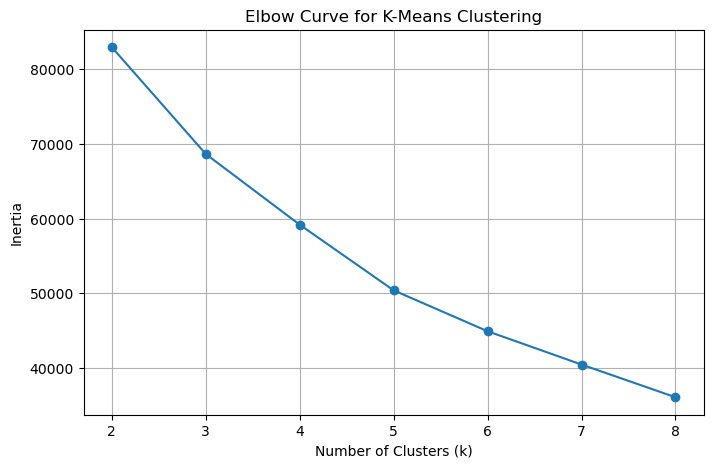

k = 2: Inertia = 82925.45
k = 3: Inertia = 68633.76
k = 4: Inertia = 59172.46
k = 5: Inertia = 50390.74
k = 6: Inertia = 44915.46
k = 7: Inertia = 40461.01
k = 8: Inertia = 36086.72


In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for different values of k
inertias = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 9),
    inertias,
    marker="o"
)

plt.title("Elbow Curve for K-Means Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(range(2, 9))
plt.grid(True)

plt.show()

# Display inertia values
for k, inertia in zip(range(2, 9), inertias):
    print(f"k = {k}: Inertia = {inertia:.2f}")

The Elbow Curve shows that inertia decreases as the number of clusters increases, indicating that the data points are being grouped more precisely. However, the rate of improvement begins to slow down after **k = 5**, forming a noticeable "elbow" in the curve.

Therefore, **k = 5** was selected as the optimal number of clusters. This choice provides a good balance between reducing inertia and maintaining interpretable borrower segments, which can help the product team design loan products tailored to different borrower profiles.

### 5.3
*For your chosen k, add a 'cluster' column to the DataFrame. For each cluster, compute the mean 
of: person_income, loan_amnt, loan_int_rate, loan_percent_income, and the actual default rate 
(loan_status). Print a summary table.*

In [21]:
from sklearn.cluster import KMeans

# Fit K-Means with chosen k
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Generate cluster labels
df["cluster"] = kmeans.fit_predict(X_scaled)

# Create cluster summary table
cluster_summary = (
    df.groupby("cluster")[
        [
            "person_income",
            "loan_amnt",
            "loan_int_rate",
            "loan_percent_income",
            "loan_status"
        ]
    ]
    .mean()
    .round(2)
)

print(cluster_summary)

         person_income  loan_amnt  loan_int_rate  loan_percent_income  \
cluster                                                                 
0             65205.95    7044.57           7.84                 0.12   
1             48303.06   14982.18          11.82                 0.32   
2             56168.88    6062.86          13.36                 0.12   
3            150931.63   20143.54          12.48                 0.16   
4           6000000.00    5000.00          12.73                 0.00   

         loan_status  
cluster               
0               0.06  
1               0.45  
2               0.24  
3               0.15  
4               0.00  


The five clusters represent distinct borrower segments with different financial characteristics and default rates.

- **Cluster 1** has the highest default rate (**45%**) and is characterized by relatively low income, higher interest rates, and the highest loan burden relative to income (**32%**), making it the riskiest borrower group.
- **Cluster 0** has the lowest interest rate (**7.84%**) and a low default rate (**6%**), indicating a lower-risk segment.
- **Cluster 2** has moderate income levels and a default rate of **24%**, representing a medium-risk group.
- **Cluster 3** consists of high-income borrowers taking larger loans, with a relatively low default rate (**15%**).
- **Cluster 4** contains extremely high-income borrowers and shows a **0% default rate**, making it the lowest-risk segment in the dataset.

These clusters could help the product team design different loan products and risk-based pricing strategies for different borrower profiles.

## 5.4
*Give each cluster a descriptive business name (e.g. 'High-Income Low-Risk', 'Young High-Debt'). 
Write a 2-3 sentence description of each cluster and suggest a different loan product or interest 
rate strategy for each.*

 **Cluster 0: Low-Risk Borrowers**

These borrowers have moderate incomes, smaller loans, and the lowest interest rates. With a default rate of only 6%, they appear financially stable and reliable.

**Strategy:** Offer lower interest rates and loyalty benefits to encourage long-term borrowing.

---

**Cluster 1: High-Risk Borrowers**

This group has the highest default rate (45%) and the largest loan burden relative to income. Their lower incomes and higher interest rates suggest greater repayment challenges.

**Strategy:** Use stricter lending criteria and offer flexible repayment plans to manage risk.

---

**Cluster 2: Medium-Risk Borrowers**

These borrowers have average incomes and loan amounts, with a moderate default rate of 24%. They represent a balanced risk profile.

**Strategy:** Provide standard loan products with competitive interest rates and repayment incentives.

---

**Cluster 3: High-Income Borrowers**

This group has higher incomes and takes larger loans while maintaining a relatively low default rate. They have strong borrowing capacity and lower risk.

**Strategy:** Offer higher loan limits and customized loan options.

---

**Cluster 4: Premium Borrowers**

These borrowers have exceptionally high incomes and no observed defaults. They are the safest and most valuable customer segment.

**Strategy:** Provide premium loan products with the lowest interest rates and exclusive benefits.

# Task 6 – Neural Network Classifier 


## 6.1
*Build an MLPClassifier from sklearn (hidden_layer_sizes=(64, 32), max_iter=300, 
random_state=42). Train on the same scaled data and report ROC-AUC and F1.*

In [26]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, f1_score

# Build the MLP model
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=300,
    random_state=42
)

# Train the model
mlp_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = mlp_model.predict(X_test_scaled)
y_prob = mlp_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
roc_auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"F1 Score: {f1:.4f}")

ROC-AUC: 0.8996
F1 Score: 0.7660


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 An MLPClassifier with hidden layers of 64 and 32 neurons was trained on the scaled dataset. The model achieved a **ROC-AUC of 0.8996** and an **F1-score of 0.7660** on the test set.

These results indicate that the neural network is effective at distinguishing between borrowers who default and those who do not, while maintaining a good balance between precision and recall.

## 6.2
*Add the neural network results to your model comparison table from Task 3.*

In [28]:
from sklearn.metrics import precision_score, recall_score

mlp_precision = precision_score(y_test, y_pred)
mlp_recall = recall_score(y_test, y_pred)

print("Precision:", mlp_precision)
print("Recall:", mlp_recall)

Precision: 0.8453307392996109
Recall: 0.7002417405318292


In [29]:
comparison_table = pd.DataFrame([
    ["Logistic Regression", 0.872, 0.779, 0.542, 0.639],
    ["Random Forest", 0.935, 0.966, 0.720, 0.825],
    ["Gradient Boosting", 0.928, 0.946, 0.693, 0.800],
    ["MLP Classifier", roc_auc, mlp_precision, mlp_recall, f1]
], columns=[
    "Model",
    "ROC-AUC",
    "Precision",
    "Recall",
    "F1-Score"
])

comparison_table = comparison_table.round(3)

comparison_table

,Model,ROC-AUC,Precision,Recall,F1-Score
0,Logistic Regression,0.872,0.779,0.542,0.639
1,Random Forest,0.935,0.966,0.720,0.825
2,Gradient Boosting,0.928,0.946,0.693,0.800
3,MLP Classifier,0.900,0.845,0.700,0.766


The MLP Classifier achieved a ROC-AUC of **0.900**, Precision of **0.845**, Recall of **0.700**, and F1-Score of **0.766**. Its performance was better than Logistic Regression but lower than both Random Forest and Gradient Boosting.

Among all models, **Random Forest** remained the best performer with the highest ROC-AUC (**0.935**) and F1-Score (**0.825**). Therefore, Random Forest would still be the preferred model for loan default prediction on this dataset.

## 6.3
*Write a final recommendation: which single model would you deploy for the fintech startup, and 
why? Consider accuracy, interpretability, training speed, and the cost of errors. There is no 
single right answer, your reasoning is what matters.*

I would recommend deploying the **Random Forest** model for the fintech startup. It achieved the best overall performance among all the models, with the highest **ROC-AUC (0.935)**, **Precision (0.966)**, **Recall (0.720)**, and **F1-Score (0.825)**. This indicates that it is the most effective at identifying potential loan defaults while minimizing incorrect predictions.

From a business perspective, missing a borrower who is likely to default can be costly, making strong recall especially important. Random Forest also provides feature importance scores, making it more interpretable than the neural network, while still being relatively fast to train. Considering its strong predictive performance, reasonable interpretability, and lower risk of costly lending mistakes, Random Forest is the most suitable model for deployment.